In [10]:
import pandas as pd
import os
import collections
import numpy as np
from Bio.Seq import Seq
from Bio import SeqIO
import re
from pygenomeviz import GenomeViz
import matplotlib.pyplot as plt
from scipy.spatial import distance
from Bio.Nexus import Nexus
from Bio import Phylo

In [11]:
def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)

In [12]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42

In [13]:
from typing import List, Optional
from Bio import Phylo

def tip_order_from_nexus_biopython(
    nexus_path: str,
    tree_label: Optional[str] = None
) -> List[str]:

    trees = list(Phylo.parse(nexus_path, "nexus"))
    if not trees:
        raise ValueError("No trees found in NEXUS file.")

    if tree_label is not None:
        matches = [t for t in trees if (t.name or "") == tree_label]
        if not matches:
            raise ValueError(f"Tree labeled '{tree_label}' not found.")
        tree = matches[0]
    else:
        tree = trees[0]

    tip_order = [clade.name for clade in tree.find_clades(order="preorder") if clade.is_terminal()]
    return tip_order

In [14]:
phylogeneticOrder=()
tips_bio = tip_order_from_nexus_biopython("/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex")         # first tree

for sample in tips_bio:
    if sample in ['NA12884', 'NA12883']:
        continue
    else:
        phylogeneticOrder = add_feature(phylogeneticOrder, sample)
   
print(phylogeneticOrder)
print(len(phylogeneticOrder))

('HG02984', 'HG01890', 'HG02647', 'HG02666', 'HG02668', 'HG03225', 'NA19043', 'NA19384', 'HG005', 'NA18952', 'NA18983', 'HG02572', 'HG03248', 'HG03098', 'HG03050', 'NA19239', 'HG01074', 'HG01109', 'HG01106', 'NA19331', 'HG01252', 'HG01457', 'HG03065', 'HG02717', 'HG03471', 'HG02011', 'HG03371', 'HG02486', 'HG02965', 'HG03139', 'NA19443', 'NA19317', 'NA19347', 'NA20346', 'HG02145', 'HG02258', 'HG02953', 'HG03130', 'HG03521', 'HG02554', 'NA18879', 'HG03209', 'NA18522', 'NA19700', 'HG02055', 'NA19705', 'NA18612', 'NA18620', 'HG04157', 'NA18989', 'NA18971', 'NA18974', 'HG02040', 'NA20870', 'HG03710', 'HG01099', 'HG03579', 'NA21093', 'HG04187', 'HG03009', 'HG03942', 'HG01167', 'HG00140', 'HG00321', 'NA20905', 'HG02492', 'HG02735', 'NA20805', 'NA20809', 'HG01255', 'HG01258', 'HG01433', 'HG003', 'HG002', 'HG03688', 'HG04199', 'HG01192', 'HG01530', 'HG03742', 'NA18608', 'NA18747', 'HG00280', 'HG00329', 'HG00290', 'HG00358', 'HG02015', 'HG02083', 'HG02514', 'HG02074', 'NA18534', 'HG02027', 'HG0

In [15]:
haplogroups={}
phylDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/HPRC_HGSVC3_sample_annotations_20March2025.txt",sep='\t')#
phylDF['GoodSampleNames']=[x.split("/")[1] if '/' in x else x for x in phylDF['sample']]
phylDF.set_index("GoodSampleNames", inplace=True)

for sample in phylogeneticOrder:
    if sample in phylDF.index:
        haplogroups[sample]=phylDF.at[sample,'haplogroup_ISOGG_v15.73']
    else:
        continue

haplogroups['NA12877']='R1b1a1b1a1a2e2'
haplogroups['NA12882']='R1b1a1b1a1a2e2'
haplogroups['NA12886']='R1b1a1b1a1a2e2'
haplogroups['200080']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200084']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200085']='R1b1a1b1a1a1c2b2b1a'

print(len(haplogroups))

140


In [16]:
ColorDict={'DYZ18_Yq':'#FC9D2B', 'Yqhet_3k1bp':'#03EDF9','Yqhet_2k7bp':'#239902','DYZ1_Yq':'#BABABA','DYZ2_Con':'#0552A5'}
goodYq12Samples=[]
with open('/LeeLab/HPRC/chromosomeY/QC/LocationFiles/Yq12_QC_File.txt','r') as inFile:
    for line in inFile:
        goodYq12Samples.append(line.strip())

print(len(goodYq12Samples))

84


In [17]:
goodSamples = [x.split("_")[0] for x in goodYq12Samples]

In [18]:
assemblyDict={}
directory='/LeeLab/Assemblies/HPRC_Release2/chrY_assemblies/'
for file in os.listdir(directory):
    if '.fai' in file or '.gzi' in file or '.DS' in file:
        continue
    else:
        assemblyDict[file.split("_")[0]]= directory+file
print(len(assemblyDict))

143


In [19]:
if 'HG01952' in goodSamples:
    print('yes')

yes


## Look at the inversion breakpoints

In [12]:
distal = ['HG03225', 'HG02698', 'HG01943']
proximal = 'HG02984'

In [32]:
tempDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/HMMER_Files/HMMER_Counts/yq12hmmerFilter/HG02666.hmmerYq12.csv")
tempDF2 = tempDF[tempDF['0']=='HG02666_chrY'].copy()
for x,y,start,end in zip(tempDF2['1'], tempDF2['2'],tempDF2['3'], tempDF2['4']):
    print(x,y, start,end)

DYZ18_Yq + 28330194 28462495
Yqhet_3k1bp + 28463128 28655412
Yqhet_2k7bp + 28690446 28795326
DYZ1_Yq - 28798480 30334439
DYZ2_Con PossibleInversion 30334393 30368179
DYZ1_Yq + 30375059 30891434
DYZ2_Con + 30892304 30933439
DYZ1_Yq - 30933419 31089107
DYZ2_Con - 31089065 31146707
DYZ1_Yq - 31147575 32351559
DYZ2_Con - 32351612 32701257
DYZ1_Yq - 32702133 33079113
DYZ2_Con - 33079168 33354815
DYZ1_Yq - 33355690 34087590
DYZ2_Con - 34087646 34351945
DYZ1_Yq - 34361503 34890252
DYZ2_Con - 34890305 35115455
DYZ1_Yq - 35116330 35870741
DYZ2_Con - 35870795 36306298
DYZ1_Yq - 36318280 37073662
DYZ2_Con - 37073716 37384955
DYZ1_Yq - 37385831 40984731
DYZ2_Con - 40984785 41745426
DYZ1_Yq - 41746301 42264812
DYZ2_Con - 42264865 42787012
DYZ1_Yq - 42796574 43450122
DYZ2_Con - 43450175 43840327
DYZ1_Yq - 43841202 44585378
DYZ2_Con - 44585431 45145047
DYZ1_Yq - 45145922 45807371
DYZ2_Con - 45807424 46363076
DYZ1_Yq - 46363962 46750825
DYZ2_Con - 46750878 47191503
DYZ1_Yq - 47192379 47516124
DYZ2_Con

In [ ]:
#proximalList=['HG00358_chrY:26794897-29668996','HG02514_chrY:28029475-32367797']
#proximalList=['HG02074_chrY:28802477-31847892','HG02027_chrY:28007872-31202452']

In [15]:
#compList=['HG03225_chrY:51449457-57790362','HG02666_chrY:47516180-54329879']

#compList=['HG01952_chrY:45883452-50953919','HG02698_chrY:33731953-41518599']
#compList=['HG01943_chrY:45482739-52034296','NA19650_chrY:47552948-51664974']

In [88]:
#NORMAL COMPARISON
myCoordList= ['HG01952_chrY:50155882-50239072',
'HG01952_chrY:50567288-50613750',
'HG01943_chrY:48872510-48928950',
'HG01943_chrY:51625579-51691388',
'HG03225_chrY:55311110-55411358',
'HG03225_chrY:57023421-57077142',
'HG02698_chrY:37061377-37149258',
'HG02698_chrY:41352850-41411405']

In [12]:
import pandas as pd

def find_strand_flips(
    df,
    strand_col="strand",
    start_col="target_hit_start",
    end_col="target_hit_end",
    sort_by=None
):
    """
    Find boundaries where strand flips between adjacent rows.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    strand_col : str
        Column containing strand values (expected 1 or -1).
    start_col : str
        Start coordinate column.
    end_col : str
        End coordinate column.
    sort_by : list or None
        Optional columns to sort by before checking flips.
        Example: ["target_name", "target_hit_start"]

    Returns
    -------
    pandas.DataFrame
        One row per strand flip.
    """

    temp = df.copy()

    if sort_by is not None:
        temp = temp.sort_values(sort_by).reset_index(drop=False)
        original_index_col = "index"
    else:
        temp = temp.reset_index(drop=False)
        original_index_col = "index"

    flip_records = []

    for i in range(len(temp) - 1):
        strand1 = temp.at[i, strand_col]
        strand2 = temp.at[i + 1, strand_col]

        if pd.isna(strand1) or pd.isna(strand2):
            continue

        if strand1 != strand2:
            row1_start = temp.at[i, start_col]
            row1_end   = temp.at[i, end_col]
            row2_start = temp.at[i + 1, start_col]
            row2_end   = temp.at[i + 1, end_col]

            flip_records.append({
                "flip_number": len(flip_records) + 1,
                "row1_original_index": temp.at[i, original_index_col],
                "row2_original_index": temp.at[i + 1, original_index_col],
                "strand_before": strand1,
                "strand_after": strand2,
                "row1_start": row1_start,
                "row1_end": row1_end,
                "row2_start": row2_start,
                "row2_end": row2_end,
                "boundary_left": row1_end,
                "boundary_right": row2_start
            })

    return pd.DataFrame(flip_records)

In [17]:
newCoords=[]
for sample in myCoordList:

    coordStart = int(sample.split(":")[1].split("-")[0])
    coordEnd = int(sample.split(":")[1].split("-")[1])

    
    goodFiles=['DYZ1_Yq.hmmer-tblout-norm.tsv.gz','DYZ2_Con.hmmer-tblout-norm.tsv.gz']
    folder = sample.split("_")[0]
    directory = '/LeeLab/HPRC/chromosomeY/Data/HMMER_Files/HMMER_Counts/'+folder
    
    for file in os.listdir(directory):
        if '.tbi' in (file) or 'bed' in file:
            continue
        else:
            subFile = '.'.join(file.split(".")[2:])
            if subFile in goodFiles:
                df = pd.read_csv(directory+"/"+file, comment='#', sep='\t')
                df['target_env_start']=df['target_env_start'].astype(int)
                df.sort_values(by=['target_env_start'], inplace=True)
                df['target_env_end']=df['target_env_end'].astype(int)
                df2= df[(df['target_name']<=folder+"_chrY") & (df['target_env_end']<=coordEnd) & (df['target_env_start']>=coordStart) & (df['high_quality_hit']==1)].copy()
                if len(df2)>1:
                    flip_df = find_strand_flips(
                                                df2,
                                                strand_col="strand",
                                                start_col="target_env_start",
                                                end_col="target_env_end",
                                                sort_by=["target_name", "target_env_start"]
                                            )
                    newCoords.append(folder+"_chrY:"+str(flip_df.at[0,'boundary_left'])+"-"+str(flip_df.at[0,'boundary_right']))
                
    print(sample)

NameError: name 'myCoordList' is not defined

In [98]:
#import pysam
#with open('/DistalInversionBreakpoints.03252026.fasta', 'a+') as file:
#    for coord in newCoords:
#        sample = coord.split("_")[0]
#        file.write(">"+str(coord)+"\n")
#        sequence = ''.join(pysam.faidx(assemblyDict[sample], coord).split()[1:])
#        file.write(sequence+'\n')
#file.close()

## Visualize

In [16]:
import os
import random
from collections import defaultdict

import pandas as pd
import pysam
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle, ConnectionPatch
from pygenomeviz import GenomeViz


def parse_region(region: str):
    contig, rest = region.split(":")
    start, end = map(int, rest.split("-"))
    return contig, start, end 


def fetch_sequence(region: str, assemblyDict: dict):
    contig, start, end = parse_region(region)
    sample = contig.split("_")[0]

    seq = ''.join(
        pysam.faidx(assemblyDict[sample], region).split()[1:]
    ).upper()

    return {
        "region": region,
        "sample": sample,
        "contig": contig,
        "start": start,
        "end": end,
        "length": end - start + 1,
        "seq": seq
    }


def revcomp(seq: str) -> str:
    comp = str.maketrans("ACGTNacgtn", "TGCANtgcan")
    return seq.translate(comp)[::-1]


def canonicalize_kmer(kmer: str):
    """
    Returns:
      canonical_kmer: lexicographically smaller of kmer and revcomp(kmer)
      orientation: '+' if observed kmer == canonical, '-' if observed kmer == revcomp(canonical)
    """
    rc = revcomp(kmer)
    if kmer <= rc:
        return kmer, "+"
    else:
        return rc, "-"



def get_canonical_kmer_positions(seq: str, k: int = 101, skip_N: bool = True):
    """
    For each observed k-mer in seq:
      - compute canonical form
      - store observed position and orientation relative to canonical form

    Output:
      dict[canonical_kmer] = [
          {"pos0": i, "orientation": "+" or "-", "observed_kmer": kmer}
      ]
    """
    out = defaultdict(list)

    if len(seq) < k:
        return out

    for i in range(len(seq) - k + 1):
        kmer = seq[i:i+k]
        if skip_N and "N" in kmer:
            continue

        canonical, orientation = canonicalize_kmer(kmer)

        out[canonical].append({
            "pos0": i,
            "orientation": orientation,
            "observed_kmer": kmer
        })

    return out


def load_architecture_blocks_for_region(
    sample: str,
    contig: str,
    region_start: int,
    region_end: int,
    hmmer_dir="/LeeLab/HPRC/chromosomeY/Data/HMMER_Files/HMMER_Counts/yq12hmmerFilter"
):
    path = os.path.join(hmmer_dir, f"{sample}.hmmerYq12.csv")
    tempDF = pd.read_csv(path)
    tempDF.columns = [str(c) for c in tempDF.columns]

    tempDF2 = tempDF[tempDF["0"].astype(str) == str(contig)].copy()
    if tempDF2.empty:
        return []

    tempDF2["3"] = pd.to_numeric(tempDF2["3"], errors="coerce")
    tempDF2["4"] = pd.to_numeric(tempDF2["4"], errors="coerce")
    tempDF2 = tempDF2.dropna(subset=["3", "4"]).copy()

    blocks = []
    for _, r in tempDF2.iterrows():
        block_start = int(r["3"])
        block_end = int(r["4"])

        if block_end < region_start or block_start > region_end:
            continue

        clipped_start = max(block_start, region_start)
        clipped_end = min(block_end, region_end)

        rel_start = clipped_start - region_start
        rel_end = clipped_end - region_start

        strand = str(r["2"]).strip()
        if strand not in ["+", "-"]:
            strand = "+"

        blocks.append({
            "label": str(r["1"]),
            "strand": strand,
            "abs_start": clipped_start,
            "abs_end": clipped_end,
            "rel_start": rel_start,
            "rel_end": rel_end
        })

    blocks = sorted(blocks, key=lambda x: x["rel_start"])
    return blocks


def load_full_yq12_span(
    sample: str,
    contig: str,
    hmmer_dir="/LeeLab/HPRC/chromosomeY/Data/HMMER_Files/HMMER_Counts/yq12hmmerFilter"
):
    path = os.path.join(hmmer_dir, f"{sample}.hmmerYq12.csv")
    tempDF = pd.read_csv(path)
    tempDF.columns = [str(c) for c in tempDF.columns]

    tempDF2 = tempDF[tempDF["0"].astype(str) == str(contig)].copy()
    if tempDF2.empty:
        raise ValueError(f"No HMMER blocks found for {sample} {contig}")

    tempDF2["3"] = pd.to_numeric(tempDF2["3"], errors="coerce")
    tempDF2["4"] = pd.to_numeric(tempDF2["4"], errors="coerce")
    tempDF2 = tempDF2.dropna(subset=["3", "4"]).copy()

    if tempDF2.empty:
        raise ValueError(f"No usable numeric HMMER coordinates for {sample} {contig}")

    full_start = int(tempDF2["3"].min())
    full_end = int(tempDF2["4"].max())

    return {
        "sample": sample,
        "contig": contig,
        "full_start": full_start,
        "full_end": full_end,
        "full_region": f"{contig}:{full_start}-{full_end}"
    }


def get_shared_kmers_unique_in_full_yq12_strand_aware(
    region_infos,
    assemblyDict,
    hmmer_dir,
    k=101,
    skip_N=True
):
    """
    For each plotted subregion:
      1. define full Yq12 span from HMMER min(start) to max(end)
      2. fetch full Yq12 sequence
      3. compute canonical k-mers over full Yq12
      4. keep only canonical k-mers unique in full Yq12
      5. in the plotted subregion, keep canonical k-mers that occur exactly once
      6. intersect shared canonical k-mers across all plotted regions

    Returns:
      shared_df:
        one row per region per shared canonical k-mer
        includes orientation relative to canonical
      full_yq12_info
    """
    subregion_unique_maps = {}
    full_yq12_info = {}

    for info in region_infos:
        sample = info["sample"]
        contig = info["contig"]
        region = info["region"]

        full_info = load_full_yq12_span(
            sample=sample,
            contig=contig,
            hmmer_dir=hmmer_dir
        )
        full_yq12_info[region] = full_info

        full_seq = ''.join(
            pysam.faidx(assemblyDict[sample], full_info["full_region"]).split()[1:]
        ).upper()

        full_kmer_positions = get_canonical_kmer_positions(full_seq, k=k, skip_N=skip_N)
        full_unique_kmers = {
            canon_kmer for canon_kmer, entries in full_kmer_positions.items()
            if len(entries) == 1
        }

        sub_kmer_positions = get_canonical_kmer_positions(info["seq"], k=k, skip_N=skip_N)

        subregion_unique_maps[region] = {
            canon_kmer: entries[0]
            for canon_kmer, entries in sub_kmer_positions.items()
            if (canon_kmer in full_unique_kmers) and (len(entries) == 1)
        }

    shared = None
    ordered_regions = [x["region"] for x in region_infos]
    for region in ordered_regions:
        keys = set(subregion_unique_maps[region].keys())
        shared = keys if shared is None else shared & keys

    if not shared:
        return (
            pd.DataFrame(columns=[
                "canonical_kmer",
                "region",
                "seq_pos0",
                "seq_pos1",
                "genomic_start",
                "genomic_end",
                "orientation",
                "observed_kmer",
                "full_yq12_start",
                "full_yq12_end"
            ]),
            full_yq12_info
        )

    rows = []
    for info in region_infos:
        region = info["region"]
        abs_start = info["start"]
        full_info = full_yq12_info[region]

        for canon_kmer in shared:
            entry = subregion_unique_maps[region][canon_kmer]
            pos0 = entry["pos0"]
            pos1 = pos0 + 1
            gstart = abs_start + pos0
            gend = gstart + k - 1

            rows.append({
                "canonical_kmer": canon_kmer,
                "region": region,
                "seq_pos0": pos0,
                "seq_pos1": pos1,
                "genomic_start": gstart,
                "genomic_end": gend,
                "orientation": entry["orientation"],   # '+' or '-'
                "observed_kmer": entry["observed_kmer"],
                "full_yq12_start": full_info["full_start"],
                "full_yq12_end": full_info["full_end"]
            })

    shared_df = pd.DataFrame(rows)
    return shared_df, full_yq12_info



def classify_shared_kmer_relationships(shared_df, compList):
    """
    Assumes 2-region comparison.
    Adds a relationship class per canonical k-mer:
      - same_strand
      - inversion
    """
    if shared_df.empty:
        return shared_df.copy()

    if len(compList) != 2:
        out = shared_df.copy()
        out["match_type"] = "unclassified_multiway"
        return out

    r1, r2 = compList

    orient1 = (
        shared_df[shared_df["region"] == r1][["canonical_kmer", "orientation"]]
        .drop_duplicates()
        .rename(columns={"orientation": "orientation_region1"})
    )

    orient2 = (
        shared_df[shared_df["region"] == r2][["canonical_kmer", "orientation"]]
        .drop_duplicates()
        .rename(columns={"orientation": "orientation_region2"})
    )

    merged = orient1.merge(orient2, on="canonical_kmer", how="inner")

    merged["match_type"] = merged.apply(
        lambda r: "same_strand"
        if r["orientation_region1"] == r["orientation_region2"]
        else "inversion",
        axis=1
    )

    out = shared_df.merge(
        merged[["canonical_kmer", "match_type", "orientation_region1", "orientation_region2"]],
        on="canonical_kmer",
        how="left"
    )

    return out



def generate_kmer_colors(shared_df, seed=42):
    rng = random.Random(seed)

    if shared_df.empty:
        return {}

    unique_kmers = shared_df["canonical_kmer"].drop_duplicates().tolist()
    color_dict = {}

    for kmer in unique_kmers:
        r = rng.randint(50, 200)
        g = rng.randint(50, 200)
        b = rng.randint(50, 200)
        color_dict[kmer] = f"#{r:02x}{g:02x}{b:02x}"

    return color_dict


def default_architecture_colors():
    return {
        "DYZ18_Yq": "#FC9D2B",
        "Yqhet_3k1bp": "#03EDF9",
        "Yqhet_2k7bp": "#239902",
        "DYZ1_Yq": "#BABABA",
        "DYZ2_Con": "#0552A5",
    }



def draw_architecture_blocks_on_ax(ax, seg, blocks, color_dict=None, alpha=0.35, linewidth=0.2):
    if color_dict is None:
        color_dict = default_architecture_colors()

    tx = seg.transform_coord

    for b in blocks:
        color = color_dict.get(b["label"], "#bdbdbd")

        x0 = tx(b["rel_start"])
        x1 = tx(b["rel_end"])
        width = x1 - x0

        if b["strand"] == "+":
            y0 = 0.52
            height = 0.44
        else:
            y0 = 0.04
            height = 0.44

        rect = Rectangle(
            (x0, y0),
            width,
            height,
            facecolor=color,
            edgecolor=color,
            linewidth=linewidth,
            alpha=alpha,
            zorder=1
        )
        ax.add_patch(rect)


# =========================================================
# 8. Draw connectors with line style indicating match type
# =========================================================
def draw_kmer_connectors(fig, track_payloads, shared_df, kmer_color_dict,
                         line_alpha=0.45, line_width=0.7):
    if len(track_payloads) != 2:
        return

    p1, p2 = track_payloads
    ax1 = p1["track"].ax
    ax2 = p2["track"].ax

    endpoints1 = p1["kmer_endpoints"]
    endpoints2 = p2["kmer_endpoints"]

    shared_kmers = set(endpoints1) & set(endpoints2)

    match_lookup = (
        shared_df[["canonical_kmer", "match_type"]]
        .drop_duplicates()
        .set_index("canonical_kmer")["match_type"]
        .to_dict()
    )

    for kmer in shared_kmers:
        x1, y1 = endpoints1[kmer]
        x2, y2 = endpoints2[kmer]

        match_type = match_lookup.get(kmer, "same_strand")
        linestyle = "-" if match_type == "same_strand" else "--"

        con = ConnectionPatch(
            xyA=(x1, y1),
            coordsA=ax1.transData,
            xyB=(x2, y2),
            coordsB=ax2.transData,
            color=kmer_color_dict[kmer],
            alpha=line_alpha,
            linewidth=line_width,
            linestyle=linestyle,
            zorder=2,
            clip_on=False
        )
        fig.add_artist(con)



def plot_shared_unique_kmers_with_architecture_strand_aware(
    compList,
    assemblyDict,
    k=101,
    hmmer_dir="/LeeLab/HPRC/chromosomeY/Data/HMMER_Files/HMMER_Counts/yq12hmmerFilter",
    architecture_alpha=0.35,
    fig_width=16,
    fig_track_height=1.5,
    add_scale_bar=True,
    add_scale_xticks_mb=True,
    point_mode="lollipop",  
    point_size=22,
    stem_linewidth=0.8,
    color_seed=42,
    use_kmer_center=False,
    draw_connectors=True,
    connector_alpha=0.45,
    connector_linewidth=0.7,
    debug_plot_x_collisions=False,
    color_points_by_orientation=False
):
    region_infos = [fetch_sequence(region, assemblyDict) for region in compList]

    shared_df, full_yq12_info = get_shared_kmers_unique_in_full_yq12_strand_aware(
        region_infos=region_infos,
        assemblyDict=assemblyDict,
        hmmer_dir=hmmer_dir,
        k=k,
        skip_N=True
    )

    shared_df = classify_shared_kmer_relationships(shared_df, compList)
    kmer_color_dict = generate_kmer_colors(shared_df, seed=color_seed)

    gv = GenomeViz(fig_width=fig_width, fig_track_height=fig_track_height)

    if add_scale_bar:
        gv.set_scale_bar()

    track_payloads = []
    architecture_labels_seen = []

    for info in region_infos:
        region = info["region"]
        sample = info["sample"]
        contig = info["contig"]
        start = info["start"]
        end = info["end"]
        length = info["length"]

        blocks = load_architecture_blocks_for_region(
            sample=sample,
            contig=contig,
            region_start=start,
            region_end=end,
            hmmer_dir=hmmer_dir
        )

        for b in blocks:
            if b["label"] not in architecture_labels_seen:
                architecture_labels_seen.append(b["label"])

        subdf = shared_df[shared_df["region"] == region].copy()

        if use_kmer_center:
            subdf["plot_pos"] = subdf["seq_pos0"] + (k // 2)
        else:
            subdf["plot_pos"] = subdf["seq_pos0"]

        subdf = subdf.sort_values("plot_pos").copy()

        full_info = full_yq12_info[region]

        if len(compList) == 2:
            n_same = subdf["match_type"].eq("same_strand").sum()
            n_inv = subdf["match_type"].eq("inversion").sum()
            subtitle = f"same={n_same} | inversion={n_inv}"
        else:
            subtitle = f"shared_fullYq12_unique_kmers={len(subdf)}"

        track = gv.add_feature_track(
            name=(
                f"{region}\n"
                f"{subtitle}\n"
                f"fullYq12={full_info['full_start']}-{full_info['full_end']}"
            ),
            segments=(0, length)
        )
        track.add_sublabel(size=8)

        track_payloads.append({
            "track": track,
            "length": length,
            "subdf": subdf,
            "region": region,
            "blocks": blocks,
            "kmer_endpoints": {}
        })

    fig = gv.plotfig()

    if add_scale_xticks_mb:
        try:
            gv.set_scale_xticks(start=0, unit="Mb")
        except Exception:
            pass

    for payload in track_payloads:
        track = payload["track"]
        subdf = payload["subdf"]
        blocks = payload["blocks"]

        ax = track.ax
        seg = track.get_segment()
        tx = seg.transform_coord

        draw_architecture_blocks_on_ax(
            ax=ax,
            seg=seg,
            blocks=blocks,
            color_dict=default_architecture_colors(),
            alpha=architecture_alpha
        )

        xs = []
        colors = []
        edgecolors = []
        kmers = []

        for _, row in subdf.iterrows():
            canon_kmer = row["canonical_kmer"]
            xs.append(tx(row["plot_pos"]))
            kmers.append(canon_kmer)

            colors.append(kmer_color_dict[canon_kmer])
            if color_points_by_orientation:
                edgecolors.append("black" if row["orientation"] == "+" else "white")
            else:
                edgecolors.append("black")

        kmer_endpoints = {}

        if point_mode == "lollipop":
            stem_top = 0.95
            point_y = 1.0

            for x, c, kmer, (_, row) in zip(xs, colors, kmers, subdf.iterrows()):
                linestyle = "-" if row["match_type"] == "same_strand" else "--"

                ax.vlines(
                    x,
                    ymin=0.0,
                    ymax=stem_top,
                    lw=stem_linewidth,
                    color=c,
                    linestyles=linestyle,
                    zorder=4
                )
                kmer_endpoints[kmer] = (x, point_y)

            if xs:
                ax.scatter(
                    xs,
                    [point_y] * len(xs),
                    s=point_size,
                    c=colors,
                    edgecolors=edgecolors,
                    linewidths=0.6,
                    zorder=5
                )

            ax.set_ylim(-0.05, 1.15)

        elif point_mode == "tick":
            tick_top = 1.0

            for x, c, kmer, (_, row) in zip(xs, colors, kmers, subdf.iterrows()):
                linestyle = "-" if row["match_type"] == "same_strand" else "--"

                ax.vlines(
                    x,
                    ymin=0.0,
                    ymax=tick_top,
                    lw=stem_linewidth,
                    color=c,
                    linestyles=linestyle,
                    zorder=4
                )
                kmer_endpoints[kmer] = (x, tick_top)

            ax.set_ylim(-0.05, 1.05)

        else:
            raise ValueError("point_mode must be 'lollipop' or 'tick'")

        payload["kmer_endpoints"] = kmer_endpoints

        if debug_plot_x_collisions and len(kmer_endpoints) > 0:
            rounded_plot_x = pd.Series([round(v[0], 3) for v in kmer_endpoints.values()])
            print(f"\n{payload['region']}")
            print("Top plotted x collisions:")
            print(rounded_plot_x.value_counts().head(20))

    if draw_connectors and len(track_payloads) == 2:
        draw_kmer_connectors(
            fig=fig,
            track_payloads=track_payloads,
            shared_df=shared_df,
            kmer_color_dict=kmer_color_dict,
            line_alpha=connector_alpha,
            line_width=connector_linewidth
        )

    legend_handles = []
    color_dict = default_architecture_colors()

    for label in architecture_labels_seen:
        legend_handles.append(
            Patch(
                facecolor=color_dict.get(label, "#bdbdbd"),
                edgecolor=color_dict.get(label, "#bdbdbd"),
                alpha=architecture_alpha,
                label=label
            )
        )

    legend_handles.append(
        Line2D([0], [0], color="black", lw=8, alpha=0.5, label="+ strand blocks = top")
    )
    legend_handles.append(
        Line2D([0], [0], color="black", lw=8, alpha=0.2, label="- strand blocks = bottom")
    )

    legend_handles.append(
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markersize=6,
            color="black",
            markerfacecolor="black",
            label=f"Shared canonical k-mers unique in full Yq12 (k={k})"
        )
    )

    legend_handles.append(
        Line2D([0], [0], color="black", lw=1.5, linestyle="-", label="Same-strand match")
    )
    legend_handles.append(
        Line2D([0], [0], color="black", lw=1.5, linestyle="--", label="Inversion-derived match")
    )

    if color_points_by_orientation:
        legend_handles.append(
            Line2D(
                [0], [0],
                marker="o",
                linestyle="None",
                markersize=6,
                markerfacecolor="gray",
                markeredgecolor="black",
                label="Observed orientation '+'"
            )
        )
        legend_handles.append(
            Line2D(
                [0], [0],
                marker="o",
                linestyle="None",
                markersize=6,
                markerfacecolor="gray",
                markeredgecolor="white",
                label="Observed orientation '-'"
            )
        )

    fig.legend(
        handles=legend_handles,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=True,
        fontsize=8,
        title="Architecture / K-mers",
        title_fontsize=9
    )

    fig.subplots_adjust(right=0.80)
    return shared_df, kmer_color_dict, full_yq12_info, fig

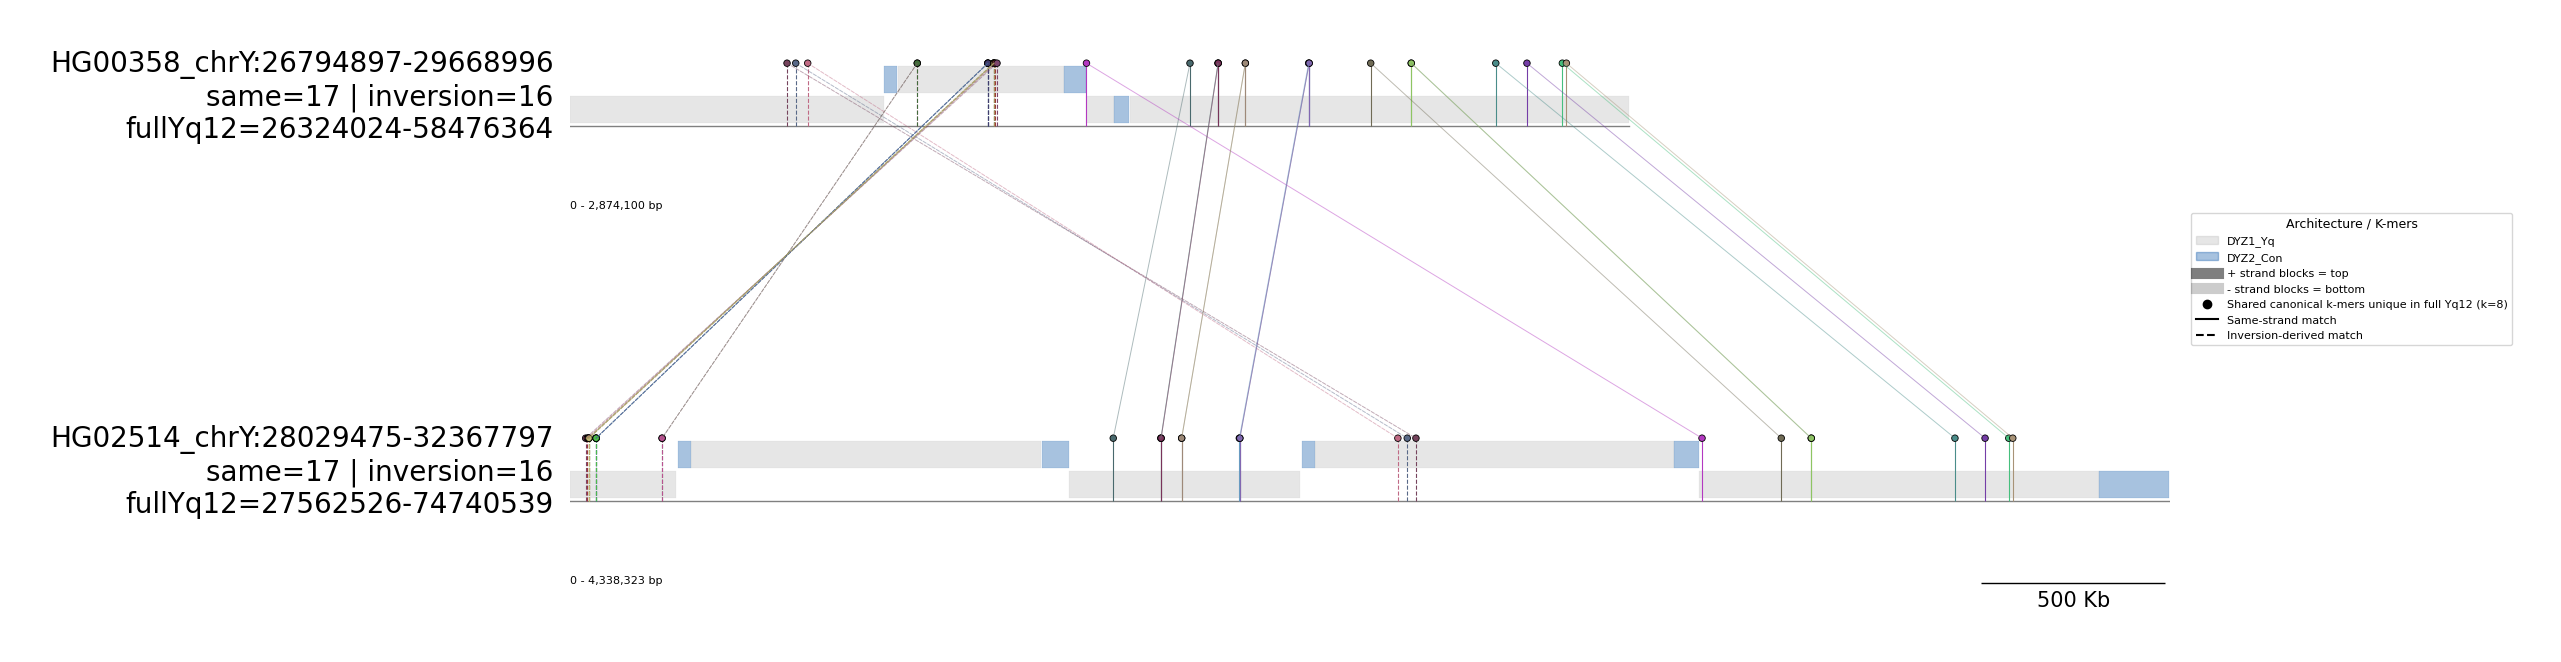

In [21]:
proximalList=['HG00358_chrY:26794897-29668996','HG02514_chrY:28029475-32367797']
#proximalList=['HG02074_chrY:28802477-31847892','HG02027_chrY:28007872-31202452']
#compList=['HG03225_chrY:51449457-57790362','HG02666_chrY:47516180-54329879']
#compList=['HG01952_chrY:45883452-50953919','HG02698_chrY:33731953-41518599']
#compList=['HG01943_chrY:45482739-52034296','NA19650_chrY:47552948-51664974']
shared_df, kmer_color_dict, full_yq12_info, fig = plot_shared_unique_kmers_with_architecture_strand_aware(
    proximalList,
    assemblyDict=assemblyDict,
    k=8,
    draw_connectors=True,
    point_mode="lollipop",
    color_points_by_orientation=False
)
fig.savefig('/HG02514_8.pdf')
plt.show()

## Inspect boundaries

In [17]:
def collapse_kmer_blocks_by_region(shared_df):
    all_blocks = []

    for region, df_region in shared_df.groupby("region"):
        df_region = df_region.sort_values("genomic_start").copy()

        current_block = None

        for _, row in df_region.iterrows():
            mt = row["match_type"]
            pos = row["genomic_start"]

            if current_block is None:
                current_block = {
                    "region": region,
                    "start": pos,
                    "end": pos,
                    "match_type": mt,
                    "count": 1
                }
                continue

            if mt == current_block["match_type"]:
                current_block["end"] = pos
                current_block["count"] += 1
            else:
                all_blocks.append(current_block)
                current_block = {
                    "region": region,
                    "start": pos,
                    "end": pos,
                    "match_type": mt,
                    "count": 1
                }

        if current_block is not None:
            all_blocks.append(current_block)

    return pd.DataFrame(all_blocks)

In [63]:
block_df = collapse_kmer_blocks_by_region(shared_df)
print(block_df)

                           region     start       end   match_type  count
0  HG01943_chrY:45482739-52034296  47986600  48312834  same_strand      3
1  HG01943_chrY:45482739-52034296  48782730  51684767    inversion     27
2  HG01943_chrY:45482739-52034296  51780489  52033641  same_strand     15
3  NA19650_chrY:47552948-51664974  47573658  47897466  same_strand      3
4  NA19650_chrY:47552948-51664974  49462007  51221439    inversion     27
5  NA19650_chrY:47552948-51664974  51414662  51664319  same_strand     15


In [103]:
tempDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/HMMER_Files/HMMER_Counts/yq12hmmerFilter/HG01943.hmmerYq12.csv")
tempDF2 = tempDF[tempDF['0']=='HG01943_chrY'].copy()
#for x,y,start,end in zip(tempDF2['1'], tempDF2['2'],tempDF2['3'], tempDF2['4']):
#    print(x,y, start,end)

In [104]:
#df = pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/HMMER_Files/HMMER_Counts/HG01943/HG01943.1917fe4f.DYZ2_Con.hmmer-tblout-norm.tsv.gz", comment='#', sep='\t')

In [105]:
#df2 = pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/HMMER_Files/HMMER_Counts/HG01943/HG01943.1917fe4f.DYZ1_Yq.hmmer-tblout-norm.tsv.gz", comment='#', sep='\t')

In [106]:
#tempDF = df2[(df2['target_env_start']>=51330189) & (df2['target_env_start']<=51626452)].sort_values(by=['target_env_start']).copy()

In [107]:
#tempDF = df[(df['target_env_start']>=51626452) & (df['target_env_start']<=51691388)].sort_values(by=['target_env_start']).copy()

In [108]:
#for x in tempDF.index:
#    print(tempDF.at[x,'hmm_hit_start'],tempDF.at[x,'hmm_hit_end'],tempDF.at[x,'target_hit_start'],tempDF.at[x,'target_hit_end'],tempDF.at[x,'strand'],tempDF.at[x,'high_quality_hit'])